## Project Setup

In [1]:
import os

repo_name = 'deepl-cifar100-image-analysis'
if not os.path.exists(repo_name):
    get_ipython().system(f'git clone https://github.com/Fgram-devAI/{repo_name}.git')
else:
    print(f'Repository "{repo_name}" already exists. Skipping clone.')

Cloning into 'deepl-cifar100-image-analysis'...
remote: Enumerating objects: 676, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 676 (delta 42), reused 59 (delta 32), pack-reused 585 (from 2)
Receiving objects: 100% (676/676), 199.37 MiB | 22.98 MiB/s, done.
Resolving deltas: 100% (336/336), done.


In [2]:
%cd /content/deepl-cifar100-image-analysis

/content/deepl-cifar100-image-analysis


In [3]:
!git fetch origin
!git checkout experiment/efficientnet-b0-fine
!pwd

Branch 'experiment/efficientnet-b0-fine' set up to track remote branch 'experiment/efficientnet-b0-fine' from 'origin'.
Switched to a new branch 'experiment/efficientnet-b0-fine'
/content/deepl-cifar100-image-analysis


# Verify Python Libraries

In [4]:
import sklearn, numpy
print("sklearn:", sklearn.__version__)
print("numpy:", numpy.__version__)


sklearn: 1.6.1
numpy: 2.0.2


# EfficientNetB0 Model Definition

In [5]:
# %%writefile models/efficientnet_b0_fine.py
"""EfficientNetB0 transfer-learning model for CIFAR-100 multiclass tasks."""

import tensorflow as tf

from models.augmentation import build_augmentation

keras = tf.keras
layers = tf.keras.layers

# EfficientNetB0 backbone has 237 layers total, grouped into 7 MBConv blocks
# (block1..block7) plus a stem and a top. Layer-index where each block starts
# (measured at input_size=128; stable across input sizes since it's topology,
# not shape, that determines block boundaries):
#   stem -> 3   block1 -> 7   block2 -> 17   block3 -> 46   block4 -> 75
#   block5 -> 119   block6 -> 162   block7 -> 221   top -> 234   (237 total)
# So unfreeze_from="block6" leaves the first ~68% of the network frozen and
# trains only the last ~75 layers (block6, block7, top) — usually the best
# accuracy/stability tradeoff for a single-stage fine-tune.


def build_efficientnet_b0(
    input_shape: tuple[int, int, int] = (32, 32, 3),
    num_classes: int = 100,
    dropout: float = 0.4,
    freeze_backbone: bool = True,
    unfreeze_from: str | None = None,   # None | "all" | "block5" | "block6" | "block7" | "top"
    freeze_bn: bool = True,             # keep BatchNorm stats frozen (recommended)
    input_size: int = 128,
    augmentation: dict | None = None,
) -> keras.Model:
    """EfficientNetB0 classifier for CIFAR-100.

    32x32 -> resize(input_size) -> rescale to [0,255] (EfficientNet has its own
    internal normalization) -> ImageNet backbone -> dropout + softmax head.
    Returned uncompiled.

    Backbone freezing modes:
      - freeze_backbone=True: everything frozen (fastest, weakest).
      - freeze_backbone=False, unfreeze_from=None or "all": everything
        trainable (strongest ceiling, but riskiest single-stage — needs a
        very low learning_rate, e.g. 1e-5).
      - freeze_backbone=False, unfreeze_from="block6" (etc.): only layers
        from that block onward are trainable; everything before it stays
        frozen. This is the recommended middle ground — adapts the
        high-level semantic features without disturbing low-level filters,
        and tolerates a higher learning_rate (~1e-4).

    freeze_bn=True additionally keeps every BatchNormalization layer frozen
    (non-trainable + inference-mode stats) even when its block is unfrozen.
    This avoids corrupting running mean/variance on small batches — almost
    always what you want when fine-tuning a pretrained backbone.
    """
    if num_classes < 1:
        raise ValueError(f"num_classes must be >= 1; got {num_classes}")

    inputs = keras.Input(shape=input_shape, name="image")

    aug_layer = build_augmentation(augmentation)
    x = aug_layer(inputs) if aug_layer is not None else inputs

    x = layers.Resizing(input_size, input_size, interpolation="bilinear")(x)
    x = layers.Rescaling(255.0)(x)

    backbone = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(input_size, input_size, 3),
        pooling="avg",
    )

    if freeze_backbone:
        backbone.trainable = False
    else:
        backbone.trainable = True
        if unfreeze_from not in (None, "all"):
            # Freeze everything before `unfreeze_from`; train from there on.
            trainable = False
            for layer in backbone.layers:
                if layer.name.startswith(unfreeze_from):
                    trainable = True
                layer.trainable = trainable
        if freeze_bn:
            for layer in backbone.layers:
                if isinstance(layer, layers.BatchNormalization):
                    layer.trainable = False

    # Run in inference mode (training=False) whenever the backbone is fully
    # frozen, so BN uses its pretrained running stats rather than batch stats.
    backbone_is_fully_frozen = freeze_backbone
    x = backbone(x, training=not backbone_is_fully_frozen)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="prob")(x)

    return keras.Model(inputs=inputs, outputs=outputs, name="efficientnet_b0")

# Register Model in `__init__.py`

In [6]:
# %% ===== CELL 6: register the builder in models/__init__.py =====
%%writefile models/__init__.py
"""Models module: sequential, ViT, transfer-learning, and baseline CNN architectures."""

from .baseline import build_baseline_cnn
from .efficientnet_b0 import build_efficientnet_b0
from .sequential import build_rnn, build_lstm, build_bilstm
from .vit import build_vit
from .transfer import build_transfer

__all__ = [
    "build_baseline_cnn",
    "build_efficientnet_b0",
    "build_rnn",
    "build_lstm",
    "build_bilstm",
    "build_vit",
    "build_transfer",
]


Overwriting models/__init__.py


# Patch `training/train.py` for EfficientNetB0

In [7]:
import pathlib

p = pathlib.Path("training/train.py")
src = p.read_text()

if "from models.efficientnet_b0 import build_efficientnet_b0" not in src:
    src = src.replace(
        "from models.baseline import build_baseline_cnn\n",
        "from models.baseline import build_baseline_cnn\n"
        "from models.efficientnet_b0 import build_efficientnet_b0\n",
    )

old_build_model = '''def _build_model(config: Dict[str, Any], *, num_classes: int = 1) -> tf.keras.Model:
    architecture = config.get("architecture", "baseline_cnn")
    if architecture != "baseline_cnn":
        raise ValueError(
            f"This branch only ships the 'baseline_cnn' architecture; "
            f"got {architecture!r}"
        )
    return build_baseline_cnn(
        dropout=float(config.get("dropout", 0.3)),
        num_classes=num_classes,
        augmentation=config.get("augmentation"),
    )'''

new_build_model = '''def _build_model(config: Dict[str, Any], *, num_classes: int = 1) -> tf.keras.Model:
    architecture = config.get("architecture", "baseline_cnn")
    if architecture == "baseline_cnn":
        return build_baseline_cnn(
            dropout=float(config.get("dropout", 0.3)),
            num_classes=num_classes,
            augmentation=config.get("augmentation"),
        )
    if architecture == "efficientnet_b0":
        return build_efficientnet_b0(
            dropout=float(config.get("dropout", 0.3)),
            num_classes=num_classes,
            freeze_backbone=bool(config.get("freeze_backbone", True)),
            unfreeze_from=config.get("unfreeze_from"),
            freeze_bn=bool(config.get("freeze_bn", True)),
            input_size=int(config.get("input_size", 96)),
            augmentation=config.get("augmentation"),
        )
    raise ValueError(
        f"Unsupported architecture {architecture!r}. "
        "Supported architectures are 'baseline_cnn' and 'efficientnet_b0'."
    )'''

if "unfreeze_from" not in src:
    assert old_build_model in src, "train.py upstream changed — patch needs review"
    src = src.replace(old_build_model, new_build_model)
    p.write_text(src)
    print("train.py patched (now supports unfreeze_from / freeze_bn).")
else:
    print("train.py already supports unfreeze_from / freeze_bn.")


train.py already supports unfreeze_from / freeze_bn.


# Define Config: EfficientNetB0 Frozen Backbone

In [8]:
import yaml

config_str = """
architecture: efficientnet_b0
run_name: efficientnet_b0_fine_frozen_in128_ep30
seed: 42

task:
  type: multiclass
  label_level: fine          # <-- 100 classes (was: coarse / 20)

validation:
  fraction: 0.1

class_imbalance:
  strategy: none             # CIFAR-100 is balanced (500/class)

batch_size: 64
shuffle_buffer: 4096
dropout: 0.4                 # a touch higher for the harder 100-class task
epochs: 30                  # was 10
optimizer: adam
learning_rate: 1e-3         # ok while the backbone is FROZEN

freeze_backbone: true       # this config keeps it frozen (the "better baseline")
input_size: 128             # was 96; try 160 if the GPU allows (drop batch_size to 32)

augmentation:               # exact keys expected by models/augmentation.py
  enabled: true             # REQUIRED — without this the whole block is ignored
  horizontal_flip: true
  translation: 0.1
  zoom: 0.1
  rotation: 0.05
  contrast: 0.1

early_stopping:
  monitor: val_loss
  patience: 8               # was 5

output_dir: results/efficientnet_b0_fine_frozen
save_weights: true
subset_size: null
"""

config = yaml.safe_load(config_str)
print(config)

{'architecture': 'efficientnet_b0', 'run_name': 'efficientnet_b0_fine_frozen_in128_ep30', 'seed': 42, 'task': {'type': 'multiclass', 'label_level': 'fine'}, 'validation': {'fraction': 0.1}, 'class_imbalance': {'strategy': 'none'}, 'batch_size': 64, 'shuffle_buffer': 4096, 'dropout': 0.4, 'epochs': 30, 'optimizer': 'adam', 'learning_rate': '1e-3', 'freeze_backbone': True, 'input_size': 128, 'augmentation': {'enabled': True, 'horizontal_flip': True, 'translation': 0.1, 'zoom': 0.1, 'rotation': 0.05, 'contrast': 0.1}, 'early_stopping': {'monitor': 'val_loss', 'patience': 8}, 'output_dir': 'results/efficientnet_b0_fine_frozen', 'save_weights': True, 'subset_size': None}


# Verify Model and Config Setup

In [9]:

get_ipython().system('grep -n efficientnet_b0 models/__init__.py')
get_ipython().system('grep -n "unfreeze_from\\|freeze_bn" training/train.py')
get_ipython().system('ls configs/multiclass/ | grep fine')


4:from .efficientnet_b0 import build_efficientnet_b0
11:    "build_efficientnet_b0",
56:            unfreeze_from=config.get("unfreeze_from"),
57:            freeze_bn=bool(config.get("freeze_bn", True)),
baseline_cnn_fine.yaml
efficientnet_b0_fine_frozen.yaml
efficientnet_b0_fine_ft.yaml
efficientnet_b0_fine_unfreeze_block6.yaml


# Install Keras and Set Environment Variable

In [10]:
get_ipython().system('pip install -q tf_keras')
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"


# Train Model: EfficientNetB0 Frozen Backbone (Run 1)

In [11]:
import os

# Get the current working directory, which is the repository root.
# This directory needs to be in the PYTHONPATH for 'python -m' to find 'models'.
current_dir = os.getcwd()

# Construct the PYTHONPATH string, ensuring the current directory is first
# and preserving any existing PYTHONPATH entries. Using os.pathsep for cross-platform compatibility.
python_path_value = f"{current_dir}{os.pathsep}{os.environ.get('PYTHONPATH', '')}"

# Construct the full shell command, explicitly setting PYTHONPATH for the subprocess.
# This ensures the environment variable is correctly passed.
command = (
    f'PYTHONPATH="{python_path_value}" '
    'python -m training.train --config configs/multiclass/efficientnet_b0_fine_frozen.yaml'
)

get_ipython().system(command)

README.md: 100% 9.98k/9.98k [00:00<00:00, 25.4MB/s]
cifar100/train-00000-of-00001.parquet: 100% 119M/119M [00:01<00:00, 62.2MB/s]
cifar100/test-00000-of-00001.parquet: 100% 23.8M/23.8M [00:01<00:00, 16.0MB/s]
Generating train split: 100% 50000/50000 [00:00<00:00, 98210.52 examples/s] 
Generating test split: 100% 10000/10000 [00:00<00:00, 108731.71 examples/s]
2026-06-22 09:40:15.133760: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1782121215.135256    2700 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2026-06-22 09:40:15.136182: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 552960000 exceeds 10% of free system memory.
2026-06-22 09:40:15.645016: W external/local_xla/

# Write EfficientNetB0 Model File

In [12]:
import pathlib

# Get the content of cell Ckq0457eNCTG
efficientnet_b0_code = '''
"""EfficientNetB0 transfer-learning model for CIFAR-100 multiclass tasks."""

import tensorflow as tf

from models.augmentation import build_augmentation

keras = tf.keras
layers = tf.keras.layers

# EfficientNetB0 backbone has 237 layers total, grouped into 7 MBConv blocks
# (block1..block7) plus a stem and a top. Layer-index where each block starts
# (measured at input_size=128; stable across input sizes since it's topology,
# not shape, that determines block boundaries):
#   stem -> 3   block1 -> 7   block2 -> 17   block3 -> 46   block4 -> 75
#   block5 -> 119   block6 -> 162   block7 -> 221   top -> 234   (237 total)
# So unfreeze_from="block6" leaves the first ~68% of the network frozen and
# trains only the last ~75 layers (block6, block7, top) — usually the best
# accuracy/stability tradeoff for a single-stage fine-tune.


def build_efficientnet_b0(
    input_shape: tuple[int, int, int] = (32, 32, 3),
    num_classes: int = 100,
    dropout: float = 0.4,
    freeze_backbone: bool = True,
    unfreeze_from: str | None = None,   # None | "all" | "block5" | "block6" | "block7" | "top"
    freeze_bn: bool = True,             # keep BatchNorm stats frozen (recommended)
    input_size: int = 128,
    augmentation: dict | None = None,
) -> keras.Model:
    """EfficientNetB0 classifier for CIFAR-100.

    32x32 -> resize(input_size) -> rescale to [0,255] (EfficientNet has its own
    internal normalization) -> ImageNet backbone -> dropout + softmax head.
    Returned uncompiled.

    Backbone freezing modes:
      - freeze_backbone=True: everything frozen (fastest, weakest).
      - freeze_backbone=False, unfreeze_from=None or "all": everything
        trainable (strongest ceiling, but riskiest single-stage — needs a
        very low learning_rate, e.g. 1e-5).
      - freeze_backbone=False, unfreeze_from="block6" (etc.): only layers
        from that block onward are trainable; everything before it stays
        frozen. This is the recommended middle ground — adapts the
        high-level semantic features without disturbing low-level filters,
        and tolerates a higher learning_rate (~1e-4).

    freeze_bn=True additionally keeps every BatchNormalization layer frozen
    (non-trainable + inference-mode stats) even when its block is unfrozen.
    This avoids corrupting running mean/variance on small batches — almost
    always what you want when fine-tuning a pretrained backbone.
    """
    if num_classes < 1:
        raise ValueError(f"num_classes must be >= 1; got {num_classes}")

    inputs = keras.Input(shape=input_shape, name="image")

    aug_layer = build_augmentation(augmentation)
    x = aug_layer(inputs) if aug_layer is not None else inputs

    x = layers.Resizing(input_size, input_size, interpolation="bilinear")(x)
    x = layers.Rescaling(255.0)(x)

    backbone = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(input_size, input_size, 3),
        pooling="avg",
    )

    if freeze_backbone:
        backbone.trainable = False
    else:
        backbone.trainable = True
        if unfreeze_from not in (None, "all"):
            # Freeze everything before `unfreeze_from`; train from there on.
            trainable = False
            for layer in backbone.layers:
                if layer.name.startswith(unfreeze_from):
                    trainable = True
                layer.trainable = trainable
        if freeze_bn:
            for layer in backbone.layers:
                if isinstance(layer, layers.BatchNormalization):
                    layer.trainable = False

    # Run in inference mode (training=False) whenever the backbone is fully
    # frozen, so BN uses its pretrained running stats rather than batch stats.
    backbone_is_fully_frozen = freeze_backbone
    x = backbone(x, training=not backbone_is_fully_frozen)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="prob")(x)

    return keras.Model(inputs=inputs, outputs=outputs, name="efficientnet_b0")
'''

# Define the path where the file should be created
file_path = pathlib.Path('models/efficientnet_b0.py')

# Create the file and write the code to it
file_path.write_text(efficientnet_b0_code)

print(f'Created {file_path} with the EfficientNetB0 model definition.')


Created models/efficientnet_b0.py with the EfficientNetB0 model definition.


# Write Config File: EfficientNetB0 Frozen Backbone

In [13]:
# %%writefile configs/multiclass/efficientnet_b0_fine_frozen.yaml
import pathlib

# Get the config string from the kernel state (it was previously loaded in H2aIfhr7Nn2k)
# For robustness, we will redefine it here to ensure it's available.
config_str_for_file = '''
architecture: efficientnet_b0
run_name: efficientnet_b0_fine_frozen_in128_ep30
seed: 42

task:
  type: multiclass
  label_level: fine          # <-- 100 classes (was: coarse / 20)

validation:
  fraction: 0.1

class_imbalance:
  strategy: none             # CIFAR-100 is balanced (500/class)

batch_size: 64
shuffle_buffer: 4096
dropout: 0.4                 # a touch higher for the harder 100-class task
epochs: 30                  # was 10
optimizer: adam
learning_rate: 1e-3         # ok while the backbone is FROZEN

freeze_backbone: true       # this config keeps it frozen (the "better baseline")
input_size: 128             # was 96; try 160 if the GPU allows (drop batch_size to 32)

augmentation:               # exact keys expected by models/augmentation.py
  enabled: true             # REQUIRED — without this the whole block is ignored
  horizontal_flip: true
  translation: 0.1
  zoom: 0.1
  rotation: 0.05
  contrast: 0.1

early_stopping:
  monitor: val_loss
  patience: 8               # was 5

output_dir: results/efficientnet_b0_fine_frozen
save_weights: true
subset_size: null
'''

# Define the path where the config file should be created
config_file_path = pathlib.Path('configs/multiclass/efficientnet_b0_fine_frozen.yaml')

# Create the necessary directories if they don't exist
config_file_path.parent.mkdir(parents=True, exist_ok=True)

# Write the config string to the file
config_file_path.write_text(config_str_for_file)

print(f'Created config file: {config_file_path}')


Created config file: configs/multiclass/efficientnet_b0_fine_frozen.yaml


# Train Model: EfficientNetB0 Frozen Backbone

In [14]:
import os

# Get the current working directory, which is the repository root.
# This directory needs to be in the PYTHONPATH for 'python -m' to find 'models'.
current_dir = os.getcwd()

# Construct the PYTHONPATH string, ensuring the current directory is first
# and preserving any existing PYTHONPATH entries. Using os.pathsep for cross-platform compatibility.
python_path_value = f"{current_dir}{os.pathsep}{os.environ.get('PYTHONPATH', '')}"

# Construct the full shell command, explicitly setting PYTHONPATH for the subprocess.
# This ensures the environment variable is correctly passed.
command = (
    f'PYTHONPATH="{python_path_value}" '
    'python -m training.train --config configs/multiclass/efficientnet_b0_fine_frozen.yaml'
)

get_ipython().system(command)


2026-06-22 09:53:10.954092: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1782121990.955644    6295 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2026-06-22 09:53:10.956665: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 552960000 exceeds 10% of free system memory.
2026-06-22 09:53:11.494942: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 552960000 exceeds 10% of free system memory.
2026-06-22 09:53:17.455763: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 552960000 exceeds 10% of free system memory.
Epoch 1/30
704/704 [==============================] - 44s 49ms/step - loss: 2.4928 - accuracy: 0.3899 - val

# Write Config File: EfficientNetB0 Unfreeze Block6

In [15]:
# %%writefile configs/multiclass/efficientnet_b0_fine_unfreeze_block6.yaml
import pathlib

config_str_unfreeze = '''
architecture: efficientnet_b0
run_name: efficientnet_b0_fine_unfreeze_block6_in128_ep30
seed: 42

task:
  type: multiclass
  label_level: fine          # <-- 100 classes (was: coarse / 20)

validation:
  fraction: 0.1

class_imbalance:
  strategy: none             # CIFAR-100 is balanced (500/class)

batch_size: 64
shuffle_buffer: 4096
dropout: 0.4                 # a touch higher for the harder 100-class task
epochs: 30                  # was 10
optimizer: adam
learning_rate: 1e-4         # lower learning rate needed when unfreezing more layers

freeze_backbone: false      # Now we are unfreezing parts of the backbone
unfreeze_from: block6       # unfreeze from block6 onwards
input_size: 128             # was 96; try 160 if the GPU allows (drop batch_size to 32)

augmentation:               # exact keys expected by models/augmentation.py
  enabled: true             # REQUIRED — without this the whole block is ignored
  horizontal_flip: true
  translation: 0.1
  zoom: 0.1
  rotation: 0.05
  contrast: 0.1

early_stopping:
  monitor: val_loss
  patience: 8               # was 5

output_dir: results/efficientnet_b0_fine_unfreeze_block6
save_weights: true
subset_size: null
'''

# Define the path where the new config file should be created
config_file_path_unfreeze = pathlib.Path('configs/multiclass/efficientnet_b0_fine_unfreeze_block6.yaml')

# Create the necessary directories if they don't exist
config_file_path_unfreeze.parent.mkdir(parents=True, exist_ok=True)

# Write the config string to the file
config_file_path_unfreeze.write_text(config_str_unfreeze)

print(f'Created config file: {config_file_path_unfreeze}')


Created config file: configs/multiclass/efficientnet_b0_fine_unfreeze_block6.yaml


# Train Model: EfficientNetB0 Unfreeze Block6 (Run 2)

In [16]:
import os

# Get the current working directory, which is the repository root.
# This directory needs to be in the PYTHONPATH for 'python -m' to find 'models'.
current_dir = os.getcwd()

# Construct the PYTHONPATH string, ensuring the current directory is first
# and preserving any existing PYTHONPATH entries. Using os.pathsep for cross-platform compatibility.
python_path_value = f"{current_dir}{os.pathsep}{os.environ.get('PYTHONPATH', '')}"

# Construct the full shell command, explicitly setting PYTHONPATH for the subprocess.
# This ensures the environment variable is correctly passed.
command = (
    f'PYTHONPATH="{python_path_value}" '
    'python -m training.train --config configs/multiclass/efficientnet_b0_fine_unfreeze_block6.yaml'
)

get_ipython().system(command)


2026-06-22 10:06:02.763695: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1782122762.765252    9819 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2026-06-22 10:06:02.766350: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 552960000 exceeds 10% of free system memory.
2026-06-22 10:06:03.266992: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 552960000 exceeds 10% of free system memory.
2026-06-22 10:06:09.124600: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 552960000 exceeds 10% of free system memory.
Epoch 1/30
E0000 00:00:1782122775.094513    9819 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Si

# Write Config File: EfficientNetB0 Full Fine-tune

In [17]:
# %%writefile configs/multiclass/efficientnet_b0_fine_ft.yaml
import pathlib
import yaml

config_str_ft = '''
architecture: efficientnet_b0
run_name: efficientnet_b0_fine_ft_in128_ep40
snapshot_weights: results/efficientnet_b0_fine_unfreeze_block6/efficientnet_b0_fine_unfreeze_block6_in128_ep30/weights.h5
seed: 42

task:
  type: multiclass
  label_level: fine

validation:
  fraction: 0.1

class_imbalance:
  strategy: none

batch_size: 64
shuffle_buffer: 4096
dropout: 0.4
epochs: 40
optimizer: adam
learning_rate: 1e-5

freeze_backbone: false
unfreeze_from: all
freeze_bn: true
input_size: 128

augmentation:
  enabled: true
  horizontal_flip: true
  translation: 0.1
  zoom: 0.1
  rotation: 0.05
  contrast: 0.1

early_stopping:
  monitor: val_loss
  patience: 10

output_dir: results/efficientnet_b0_fine_ft
save_weights: true
subset_size: null
'''

# Define the path where the new config file should be created
config_file_path_ft = pathlib.Path('configs/multiclass/efficientnet_b0_fine_ft.yaml')

# Create the necessary directories if they don't exist
config_file_path_ft.parent.mkdir(parents=True, exist_ok=True)

# Write the config string to the file
config_file_path_ft.write_text(config_str_ft)

print(f'Created config file: {config_file_path_ft}')


Created config file: configs/multiclass/efficientnet_b0_fine_ft.yaml


# Train Model: EfficientNetB0 Full Fine-tune (Run 3)

In [18]:
get_ipython().system('python -m training.train --config configs/multiclass/efficientnet_b0_fine_ft.yaml')


2026-06-22 10:20:53.662306: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1782123653.663841   13765 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2026-06-22 10:20:53.664817: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 552960000 exceeds 10% of free system memory.
2026-06-22 10:20:54.176684: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 552960000 exceeds 10% of free system memory.
2026-06-22 10:20:59.349114: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 552960000 exceeds 10% of free system memory.
Epoch 1/40
E0000 00:00:1782123666.569305   13765 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Si

# Verify All Three Runs Output

# List Contents of Run Directory

In [ ]:
from pathlib import Path
run_dir = Path("results/efficientnet_b0_fine_unfreeze_block6/efficientnet_b0_fine_unfreeze_block6_in128_ep30")
get_ipython().system(f'ls -la {run_dir}')

# Load History and Metrics

In [28]:
import json

with open(run_dir / "history.json") as f:
    history = json.load(f)
with open(run_dir / "metrics.json") as f:
    metrics = json.load(f)

print("History keys:", list(history.keys()))
print("=== Final test metrics (fine / 100 classes) ===")
print(f"Accuracy:        {metrics['accuracy']:.4f}")
if "top_3_accuracy" in metrics:
    print(f"Top-3 accuracy:  {metrics['top_3_accuracy']:.4f}")
if "top_5_accuracy" in metrics:
    print(f"Top-5 accuracy:  {metrics['top_5_accuracy']:.4f}")
print(f"Macro precision: {metrics['macro_precision']:.4f}")
print(f"Macro recall:    {metrics['macro_recall']:.4f}")
print(f"Macro F1:        {metrics['macro_f1']:.4f}")
print(f"Weighted F1:     {metrics['weighted_f1']:.4f}")

History keys: ['loss', 'accuracy', 'val_loss', 'val_accuracy']
=== Final test metrics (fine / 100 classes) ===
Accuracy:        0.7671
Top-3 accuracy:  0.9187
Top-5 accuracy:  0.9510
Macro precision: 0.7724
Macro recall:    0.7671
Macro F1:        0.7661
Weighted F1:     0.7661


# Append Metrics to Summary CSV

In [29]:
import csv

summary_path = Path("results/summary.csv")
COLUMNS = ["task_name", "run_name", "task_type", "label_level", "target_labels",
           "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "threshold",
           "top_3_accuracy", "top_5_accuracy", "macro_f1", "weighted_f1"]

row = {c: "" for c in COLUMNS}
row.update({
    "task_name": run_dir.parent.name,     # e.g. efficientnet_b0_fine_ft
    "run_name": run_dir.name,
    "task_type": "multiclass",
    "label_level": "fine",
    "accuracy": metrics.get("accuracy", ""),
    "top_3_accuracy": metrics.get("top_3_accuracy", ""),
    "top_5_accuracy": metrics.get("top_5_accuracy", ""),
    "macro_f1": metrics.get("macro_f1", ""),
    "weighted_f1": metrics.get("weighted_f1", ""),
})

write_header = not summary_path.exists()
with summary_path.open("a", newline="") as f:
    w = csv.DictWriter(f, fieldnames=COLUMNS)
    if write_header:
        w.writeheader()
    w.writerow(row)
print(f"Appended {row['run_name']} to {summary_path}")


Appended efficientnet_b0_fine_unfreeze_block6_in128_ep30 to results/summary.csv


# Plot Training Curves

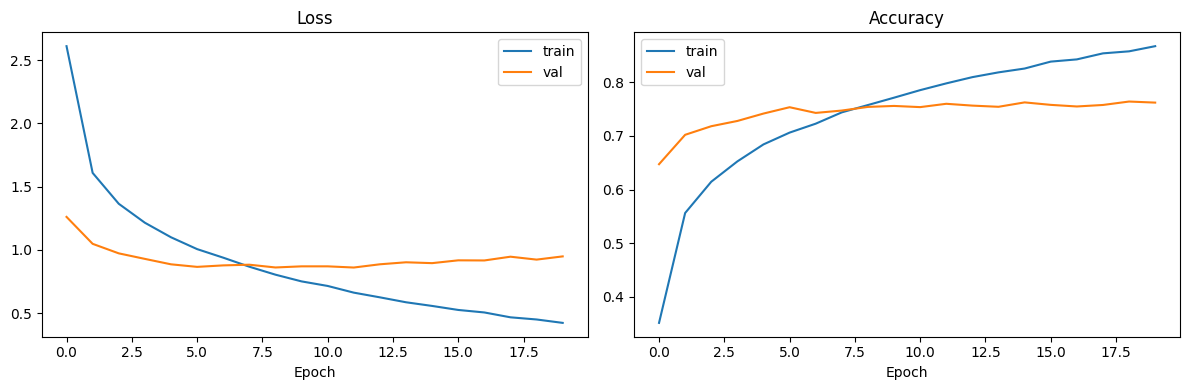

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history["accuracy"], label="train")
axes[1].plot(history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(run_dir / "training_curves.png", dpi=150)
plt.show()


# Define Fine-Grained Labels

In [32]:
FINE_LABELS = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle",
    "bicycle", "bottle", "bowl", "boy", "bridge", "bus", "butterfly", "camel",
    "can", "castle", "caterpillar", "cattle", "chair", "chimpanzee", "clock",
    "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster",
    "house", "kangaroo", "keyboard", "lamp", "lawn_mower", "leopard", "lion",
    "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain", "mouse",
    "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear",
    "pickup_truck", "pine_tree", "plain", "plate", "poppy", "porcupine",
    "possum", "rabbit", "raccoon", "ray", "road", "rocket", "rose", "sea",
    "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank",
    "telephone", "television", "tiger", "tractor", "train", "trout", "tulip",
    "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm",
]

assert len(FINE_LABELS) == 100


# Plot Confusion Matrix and Worst-20 F1

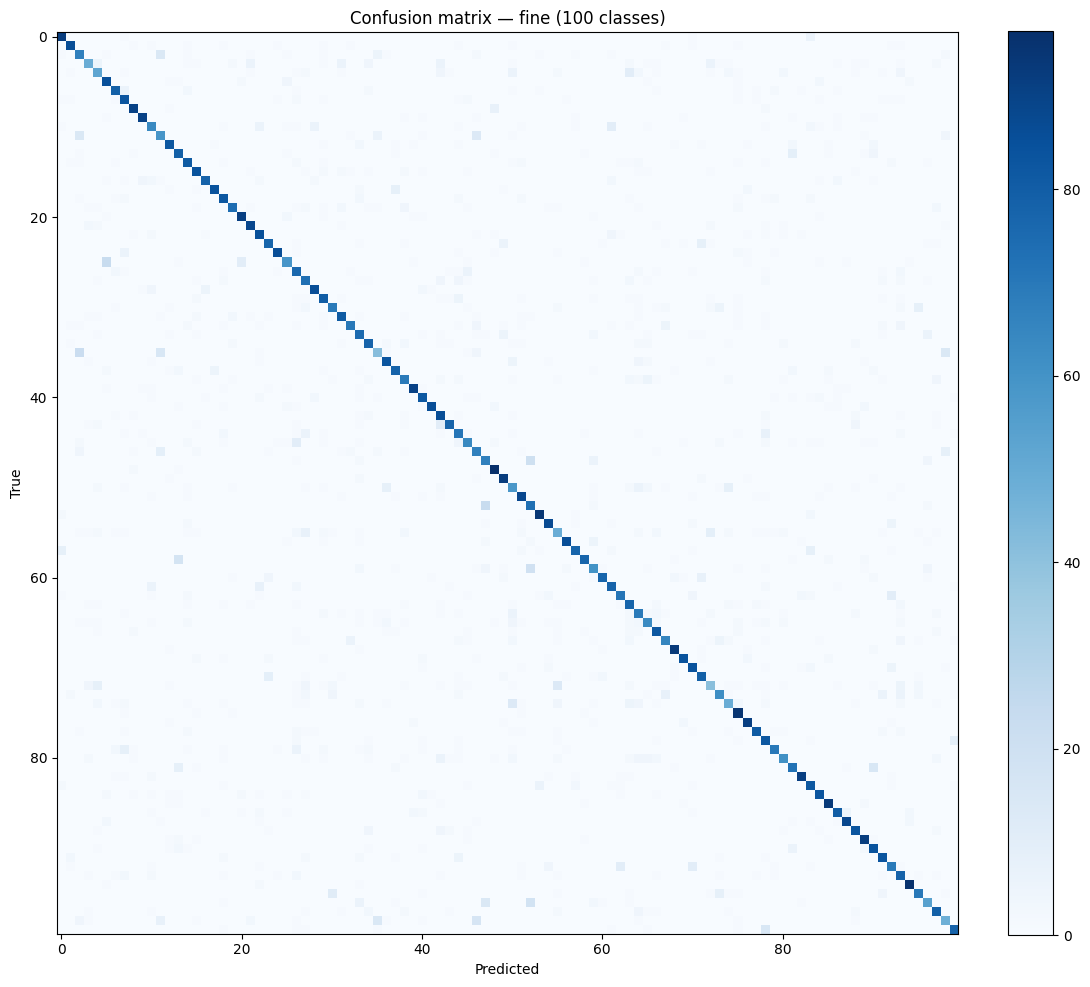

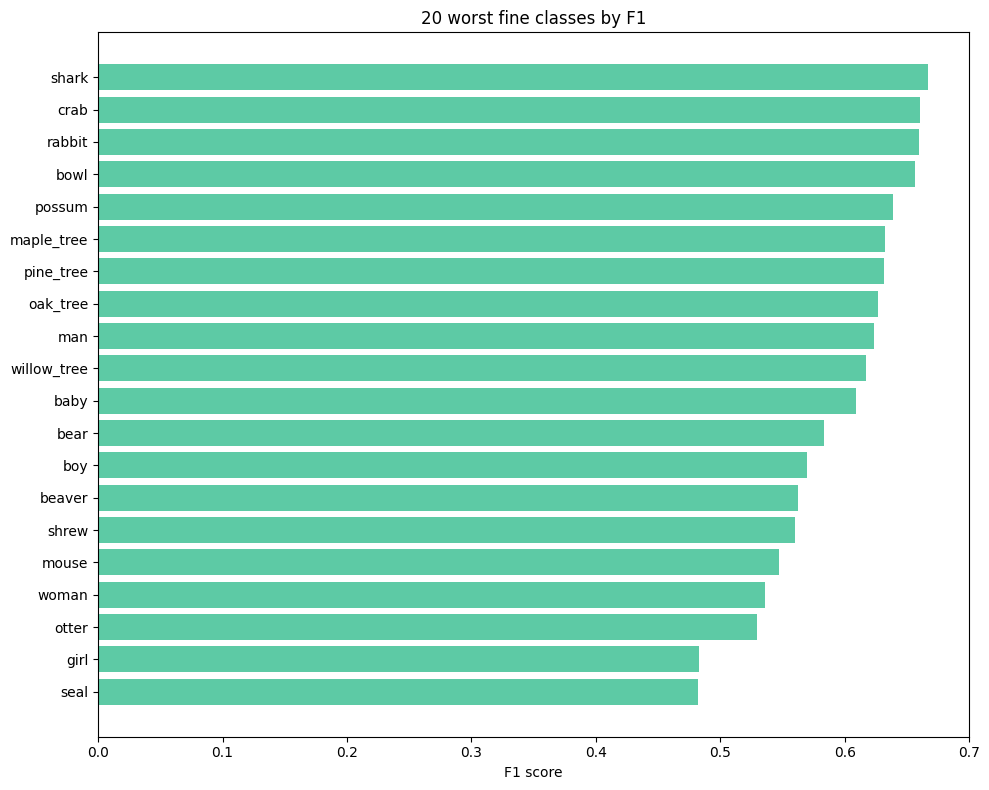

In [33]:
import numpy as np

cm = np.array(metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(cm, cmap="Blues")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix — fine (100 classes)")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(run_dir / "confusion_matrix.png", dpi=150)
plt.show()

# %% ===== CELL 18: per-class F1 — show the 20 WORST classes (100 bars is unreadable) =====
diag = np.diag(cm)
col_sums = cm.sum(axis=0); row_sums = cm.sum(axis=1)
precision = np.divide(diag, col_sums, out=np.zeros_like(diag, float), where=col_sums != 0)
recall    = np.divide(diag, row_sums, out=np.zeros_like(diag, float), where=row_sums != 0)
f1 = np.divide(2 * precision * recall, precision + recall,
               out=np.zeros_like(diag, float), where=(precision + recall) != 0)

worst = np.argsort(f1)[:20]   # 20 weakest classes
fig, ax = plt.subplots(figsize=(10, 8))
y = np.arange(len(worst))
ax.barh(y, f1[worst], color="#5DCAA5")
ax.set_yticks(y); ax.set_yticklabels([FINE_LABELS[i] for i in worst])
ax.set_xlabel("F1 score"); ax.set_title("20 worst fine classes by F1")
plt.tight_layout()
plt.savefig(run_dir / "per_class_f1_worst20.png", dpi=150)
plt.show()

# Visualize Misclassified Examples for 10 Worst Classes

In [40]:
# %% ===== CELL 19: load fine test task + rebuild model to inspect predictions =====
from data import load_cifar100
from data.tasks import make_cifar100_multiclass_task

test_split = load_cifar100("test")
test_task = make_cifar100_multiclass_task(test_split, label_level="fine", seed=42)
test_images = test_task.images   # (10000, 32, 32, 3) uint8
test_labels = test_task.labels   # (10000,) in [0, 100)
print(test_images.shape, test_labels.shape)

from models.efficientnet_b0 import build_efficientnet_b0
model = build_efficientnet_b0(
    num_classes=100,
    freeze_backbone=False,
    unfreeze_from="block6",
    freeze_bn=True,
    input_size=128,
)
model.load_weights(run_dir / "weights.h5")
print("Model loaded OK")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


(10000, 32, 32, 3) (10000,)
Model loaded OK


157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 103ms/step


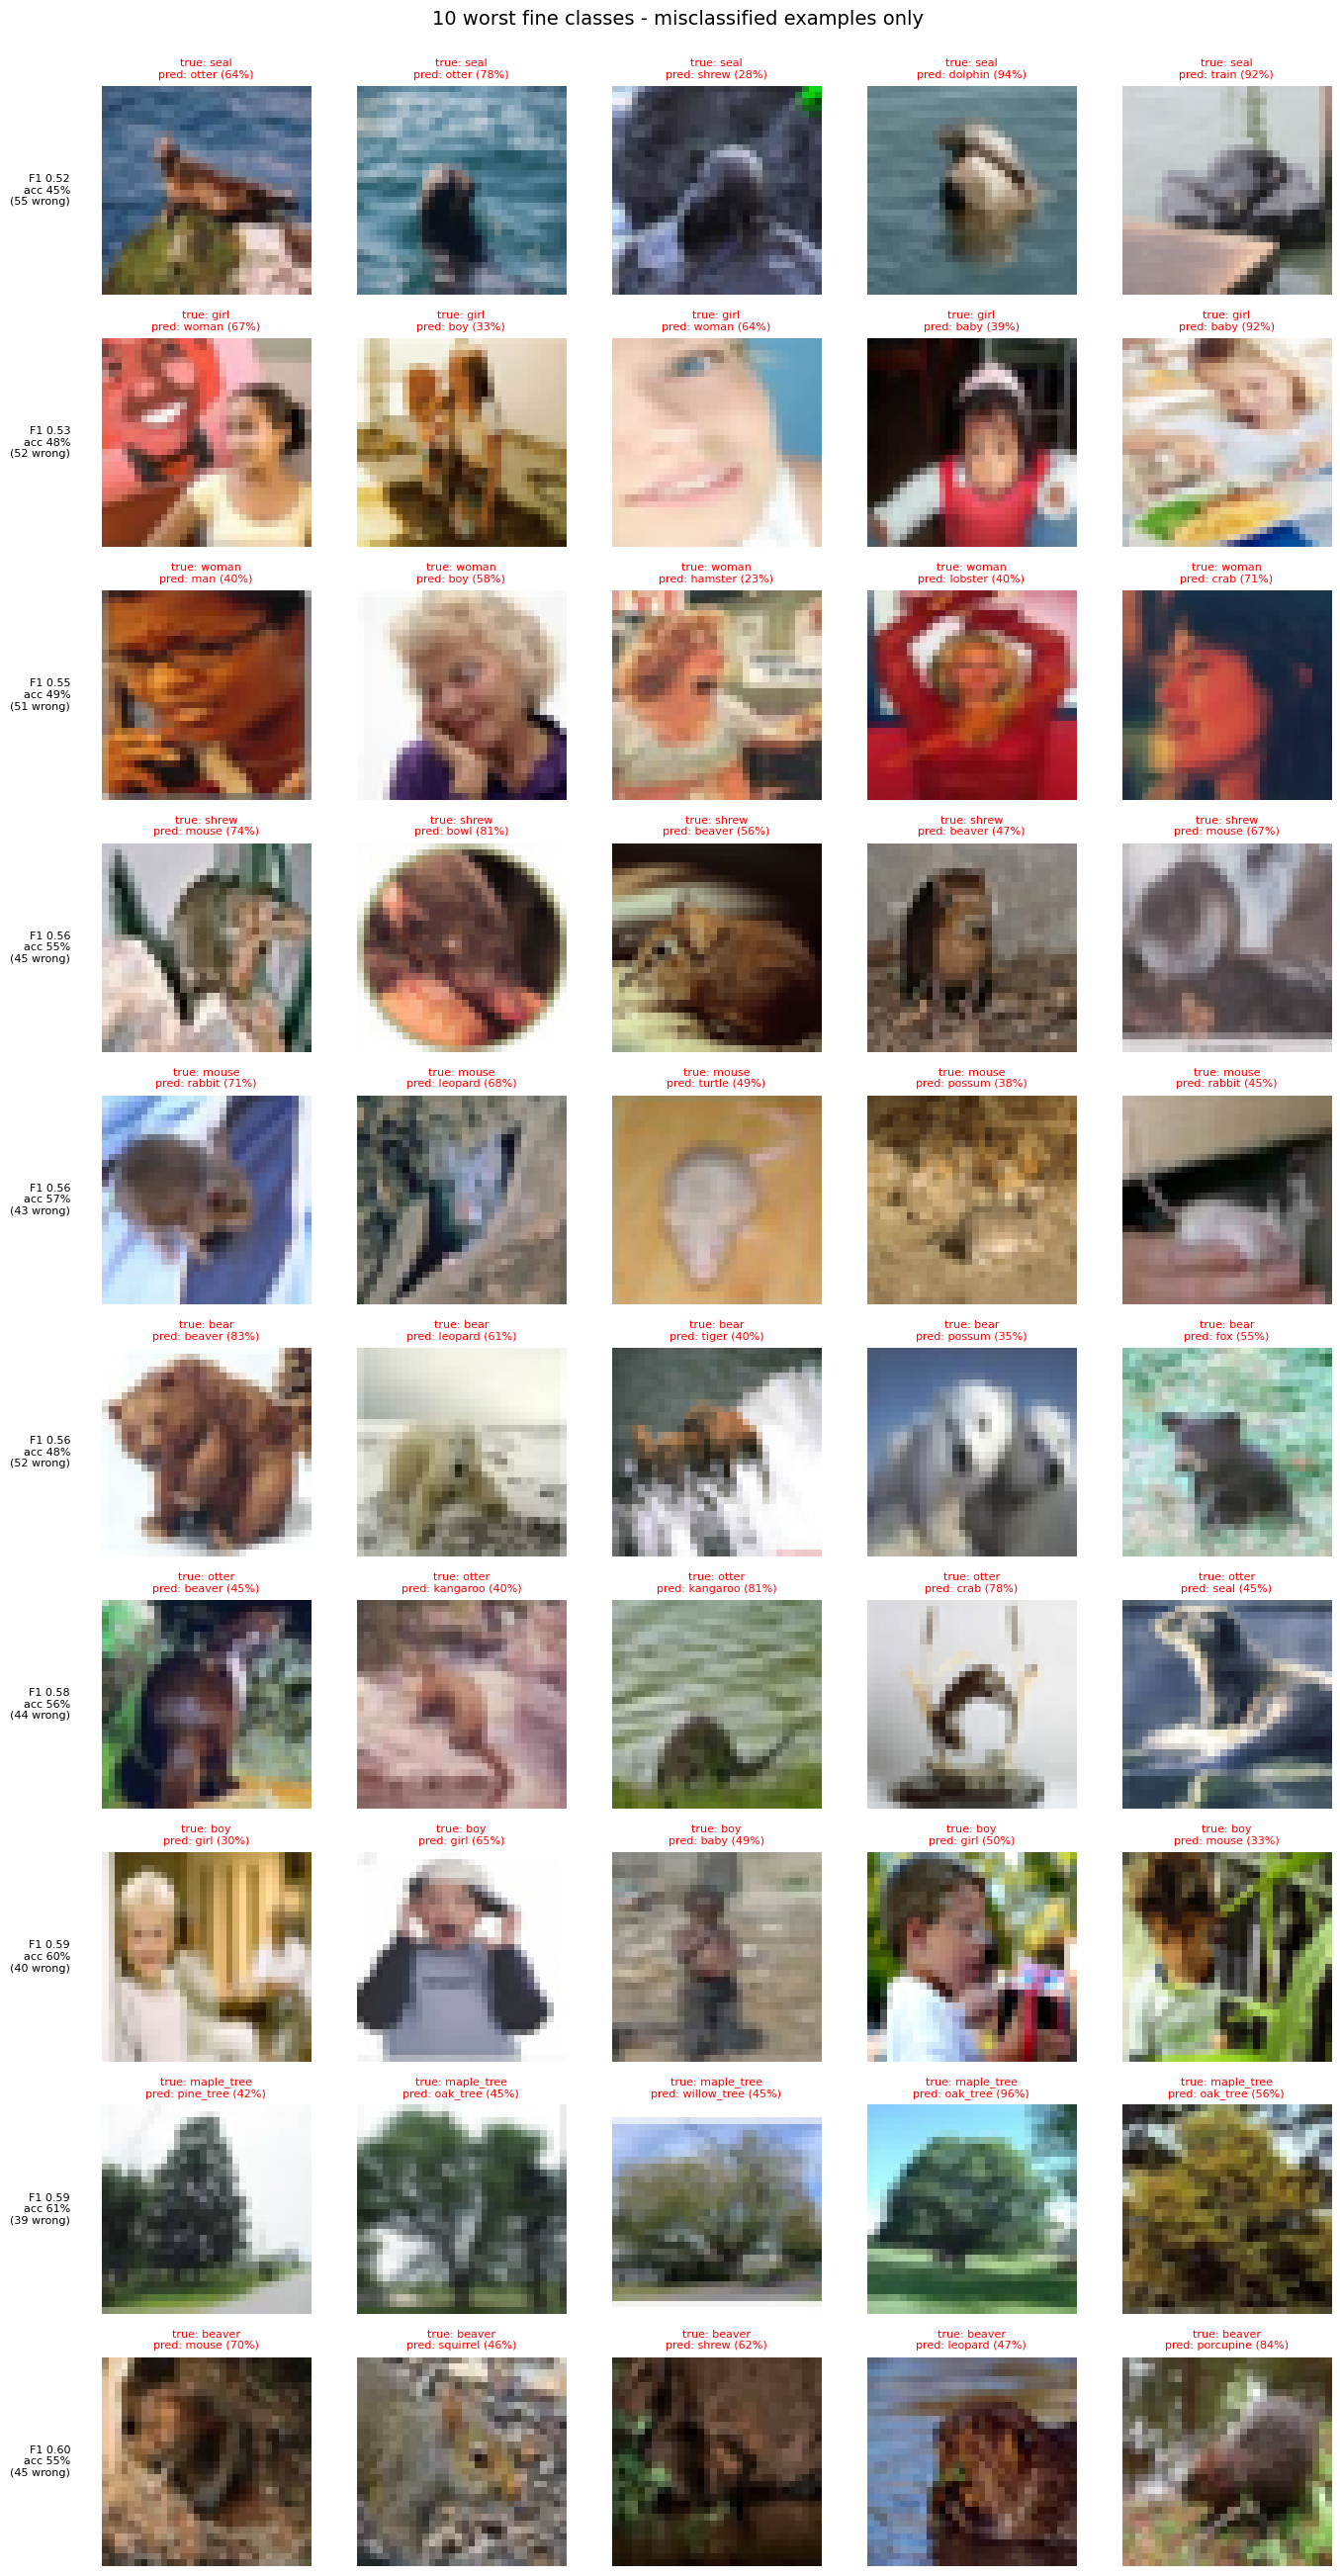

In [41]:
# %% ===== CELL 20: worst 10 classes - misclassified examples only =====
from sklearn.metrics import confusion_matrix

test_images_normalized = test_images.astype(np.float32) / 255.0
probs = model.predict(test_images_normalized, batch_size=64, verbose=1)
preds = probs.argmax(axis=1)
confidences = probs.max(axis=1)

cm = confusion_matrix(test_labels, preds)
diag = np.diag(cm)
col_sums = cm.sum(axis=0)
row_sums = cm.sum(axis=1)

precision = np.divide(diag, col_sums, out=np.zeros_like(diag, float), where=col_sums != 0)
recall    = np.divide(diag, row_sums, out=np.zeros_like(diag, float), where=row_sums != 0)
f1 = np.divide(2 * precision * recall, precision + recall,
               out=np.zeros_like(diag, float), where=(precision + recall) != 0)

worst = np.argsort(f1)[:10]

fig, axes = plt.subplots(10, 5, figsize=(14, 26))

for row, cat_id in enumerate(worst):
    category = FINE_LABELS[cat_id]
    is_this_class = test_labels == cat_id
    wrong_idx = np.flatnonzero(is_this_class & (preds != cat_id))
    n_wrong = int(is_this_class.sum() - (preds[is_this_class] == cat_id).sum())
    acc = (preds[is_this_class] == cat_id).mean()
    shown = wrong_idx[:5]
    for col in range(5):
        ax = axes[row, col]
        if col < len(shown):
            idx = shown[col]
            ax.imshow(test_images[idx])
            ax.set_title(
                f"true: {category}\npred: {FINE_LABELS[preds[idx]]} ({confidences[idx]:.0%})",
                fontsize=8, color="red"
            )
        ax.axis("off")
        if col == 0:
            ax.text(-0.15, 0.5,
                    f"F1 {f1[cat_id]:.2f}\nacc {acc:.0%}\n({n_wrong} wrong)",
                    transform=ax.transAxes, fontsize=8, va="center", ha="right")

fig.suptitle("10 worst fine classes - misclassified examples only", fontsize=14, y=1.0)
plt.tight_layout()
plt.savefig(Path(run_dir).parent / "worst10_misclassified.png", dpi=150)
plt.show()

# Set run_dir for Full Unfreeze

In [42]:
from pathlib import Path
run_dir = Path("results/efficientnet_b0_fine_ft/efficientnet_b0_fine_ft_in128_ep40")
get_ipython().system(f'ls -la {run_dir}')


total 17288
drwxr-xr-x 2 root root     4096 Jun 22 09:39 .
drwxr-xr-x 3 root root     4096 Jun 22 09:39 ..
-rw-r--r-- 1 root root     4420 Jun 22 10:20 class_balance.json
-rw-r--r-- 1 root root      733 Jun 22 10:20 config.yaml
-rw-r--r-- 1 root root    52820 Jun 22 09:39 confusion_matrix.png
-rw-r--r-- 1 root root     3217 Jun 22 11:31 history.csv
-rw-r--r-- 1 root root     3906 Jun 22 11:31 history.json
-rw-r--r-- 1 root root    93174 Jun 22 11:31 metrics.json
-rw-r--r-- 1 root root    39870 Jun 22 09:39 per_class_f1_worst10.png
-rw-r--r-- 1 root root    69481 Jun 22 09:39 training_curves.png
-rw-r--r-- 1 root root 16983088 Jun 22 11:31 weights.h5
-rw-r--r-- 1 root root   427091 Jun 22 09:39 worst10_misclassified.png


# Load History and Metrics for Full Unfreeze

In [43]:
import json

with open(run_dir / "history.json") as f:
    history = json.load(f)
with open(run_dir / "metrics.json") as f:
    metrics = json.load(f)

print("History keys:", list(history.keys()))
print("=== Final test metrics (fine / 100 classes, FULL UNFREEZE) ===")
print(f"Accuracy:        {metrics['accuracy']:.4f}")
if "top_3_accuracy" in metrics:
    print(f"Top-3 accuracy:  {metrics['top_3_accuracy']:.4f}")
if "top_5_accuracy" in metrics:
    print(f"Top-5 accuracy:  {metrics['top_5_accuracy']:.4f}")
print(f"Macro precision: {metrics['macro_precision']:.4f}")
print(f"Macro recall:    {metrics['macro_recall']:.4f}")
print(f"Macro F1:        {metrics['macro_f1']:.4f}")
print(f"Weighted F1:     {metrics['weighted_f1']:.4f}")

History keys: ['loss', 'accuracy', 'val_loss', 'val_accuracy']
=== Final test metrics (fine / 100 classes, FULL UNFREEZE) ===
Accuracy:        0.7850
Top-3 accuracy:  0.9329
Top-5 accuracy:  0.9620
Macro precision: 0.7899
Macro recall:    0.7850
Macro F1:        0.7840
Weighted F1:     0.7840


# Append Metrics to Summary CSV for Full Unfreeze

In [44]:
import csv

summary_path = Path("results/summary.csv")
COLUMNS = ["task_name", "run_name", "task_type", "label_level", "target_labels",
           "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "threshold",
           "top_3_accuracy", "top_5_accuracy", "macro_f1", "weighted_f1"]

row = {c: "" for c in COLUMNS}
row.update({
    "task_name": run_dir.parent.name,
    "run_name": run_dir.name,
    "task_type": "multiclass",
    "label_level": "fine",
    "accuracy": metrics.get("accuracy", ""),
    "top_3_accuracy": metrics.get("top_3_accuracy", ""),
    "top_5_accuracy": metrics.get("top_5_accuracy", ""),
    "macro_f1": metrics.get("macro_f1", ""),
    "weighted_f1": metrics.get("weighted_f1", ""),
})

write_header = not summary_path.exists()
with summary_path.open("a", newline="") as f:
    w = csv.DictWriter(f, fieldnames=COLUMNS)
    if write_header:
        w.writeheader()
    w.writerow(row)
print(f"Appended {row['run_name']} to {summary_path}")

Appended efficientnet_b0_fine_ft_in128_ep40 to results/summary.csv


# Plot Training Curves for Full Unfreeze

## Define Fine-Grained Labels (for Visualization)

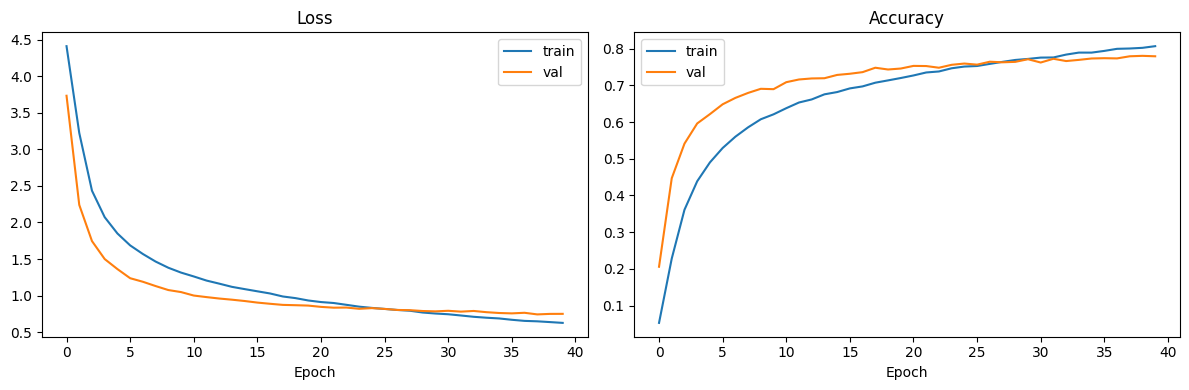

In [45]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history["accuracy"], label="train")
axes[1].plot(history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(run_dir / "training_curves.png", dpi=150)
plt.show()

# Define Fine-Grained Labels (Redundant)

In [46]:
FINE_LABELS = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle",
    "bicycle", "bottle", "bowl", "boy", "bridge", "bus", "butterfly", "camel",
    "can", "castle", "caterpillar", "cattle", "chair", "chimpanzee", "clock",
    "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster",
    "house", "kangaroo", "keyboard", "lamp", "lawn_mower", "leopard", "lion",
    "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain", "mouse",
    "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear",
    "pickup_truck", "pine_tree", "plain", "plate", "poppy", "porcupine",
    "possum", "rabbit", "raccoon", "ray", "road", "rocket", "rose", "sea",
    "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank",
    "telephone", "television", "tiger", "tractor", "train", "trout", "tulip",
    "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm",
]
assert len(FINE_LABELS) == 100

# Plot Confusion Matrix for Full Unfreeze

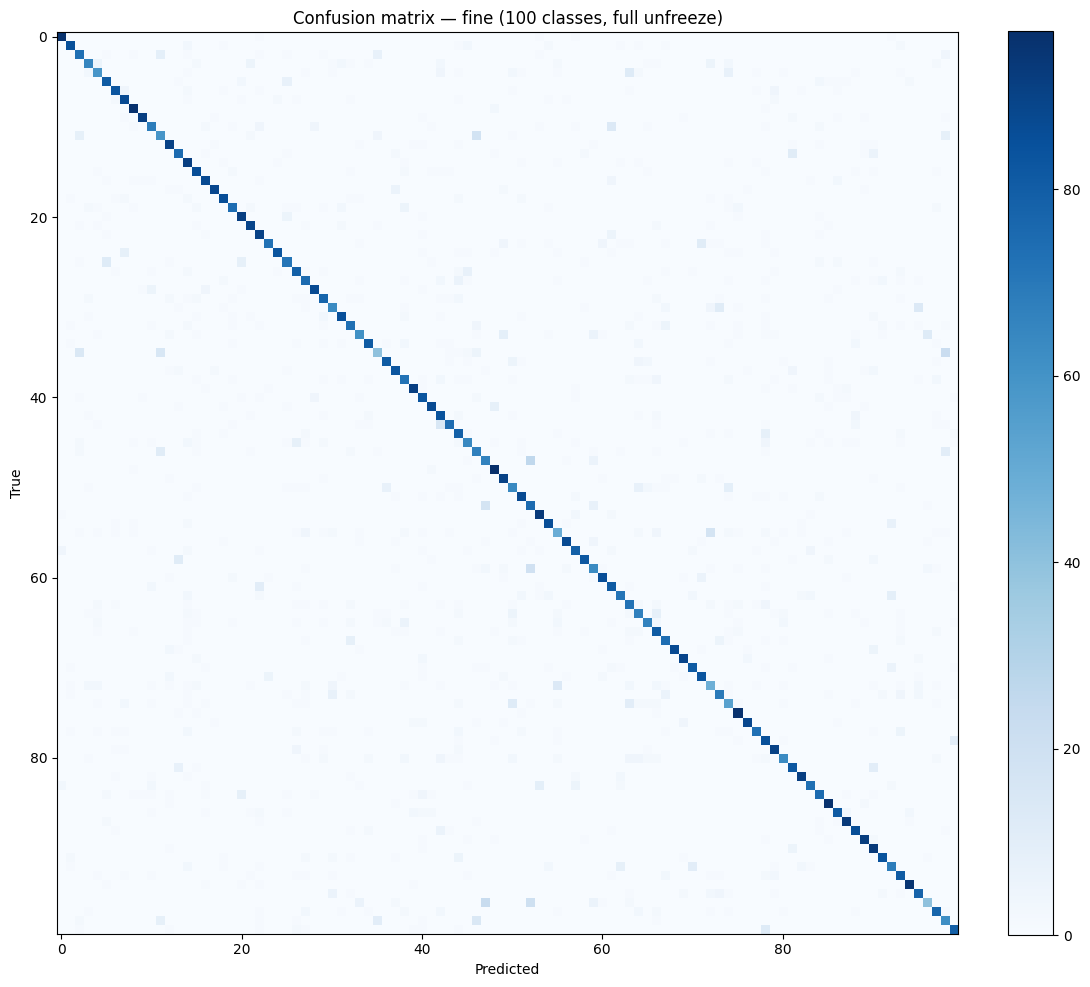

In [47]:
import numpy as np

cm = np.array(metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(cm, cmap="Blues")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix — fine (100 classes, full unfreeze)")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(run_dir / "confusion_matrix.png", dpi=150)
plt.show()

# Load Data and Rebuild Model for Full Unfreeze Predictions

In [48]:
from data import load_cifar100
from data.tasks import make_cifar100_multiclass_task

test_split = load_cifar100("test")
test_task = make_cifar100_multiclass_task(test_split, label_level="fine", seed=42)
test_images = test_task.images
test_labels = test_task.labels
print(test_images.shape, test_labels.shape)

from models.efficientnet_b0 import build_efficientnet_b0
# Must match CONFIG C exactly: freeze_backbone=False, unfreeze_from="all", freeze_bn=True
model = build_efficientnet_b0(
    num_classes=100,
    freeze_backbone=False,
    unfreeze_from="all",
    freeze_bn=True,
    input_size=128,
)
model.load_weights(run_dir / "weights.h5")


(10000, 32, 32, 3) (10000,)


# Plot Worst-10 F1 for Full Unfreeze

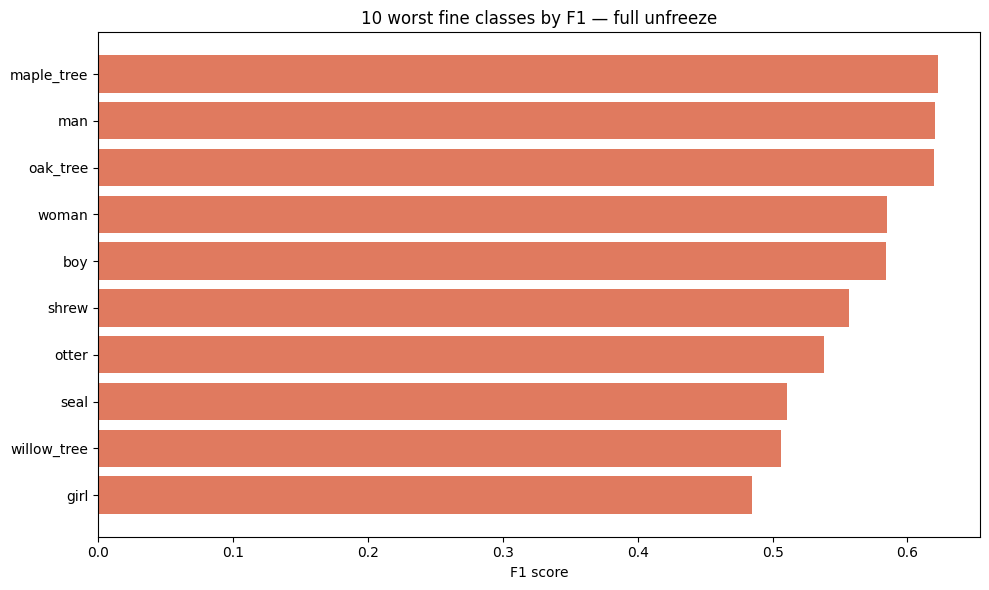

In [49]:
# %% ===== Worst-10 F1 plot — FULL UNFREEZE =====
run_dir_ft = Path("results/efficientnet_b0_fine_ft/efficientnet_b0_fine_ft_in128_ep40")

with open(run_dir_ft / "metrics.json") as f:
    metrics_ft = json.load(f)

cm_ft = np.array(metrics_ft["confusion_matrix"])

FINE_LABELS = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle",
    "bicycle", "bottle", "bowl", "boy", "bridge", "bus", "butterfly", "camel",
    "can", "castle", "caterpillar", "cattle", "chair", "chimpanzee", "clock",
    "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster",
    "house", "kangaroo", "keyboard", "lamp", "lawn_mower", "leopard", "lion",
    "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain", "mouse",
    "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear",
    "pickup_truck", "pine_tree", "plain", "plate", "poppy", "porcupine",
    "possum", "rabbit", "raccoon", "ray", "road", "rocket", "rose", "sea",
    "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank",
    "telephone", "television", "tiger", "tractor", "train", "trout", "tulip",
    "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm",
]

diag = np.diag(cm_ft)
col_sums = cm_ft.sum(axis=0); row_sums = cm_ft.sum(axis=1)
precision_ft = np.divide(diag, col_sums, out=np.zeros_like(diag, float), where=col_sums != 0)
recall_ft    = np.divide(diag, row_sums, out=np.zeros_like(diag, float), where=row_sums != 0)
f1_ft = np.divide(2 * precision_ft * recall_ft, precision_ft + recall_ft,
                   out=np.zeros_like(diag, float), where=(precision_ft + recall_ft) != 0)

worst10_ft = np.argsort(f1_ft)[:10]   # 10 weakest classes for the full-unfreeze run

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(worst10_ft))
ax.barh(y, f1_ft[worst10_ft], color="#E07A5F")
ax.set_yticks(y); ax.set_yticklabels([FINE_LABELS[i] for i in worst10_ft])
ax.set_xlabel("F1 score"); ax.set_title("10 worst fine classes by F1 — full unfreeze")
plt.tight_layout()
plt.savefig(run_dir_ft / "per_class_f1_worst10.png", dpi=150)
plt.show()

# Plot Worst-10 Misclassified Examples Grid for Full Unfreeze

157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step


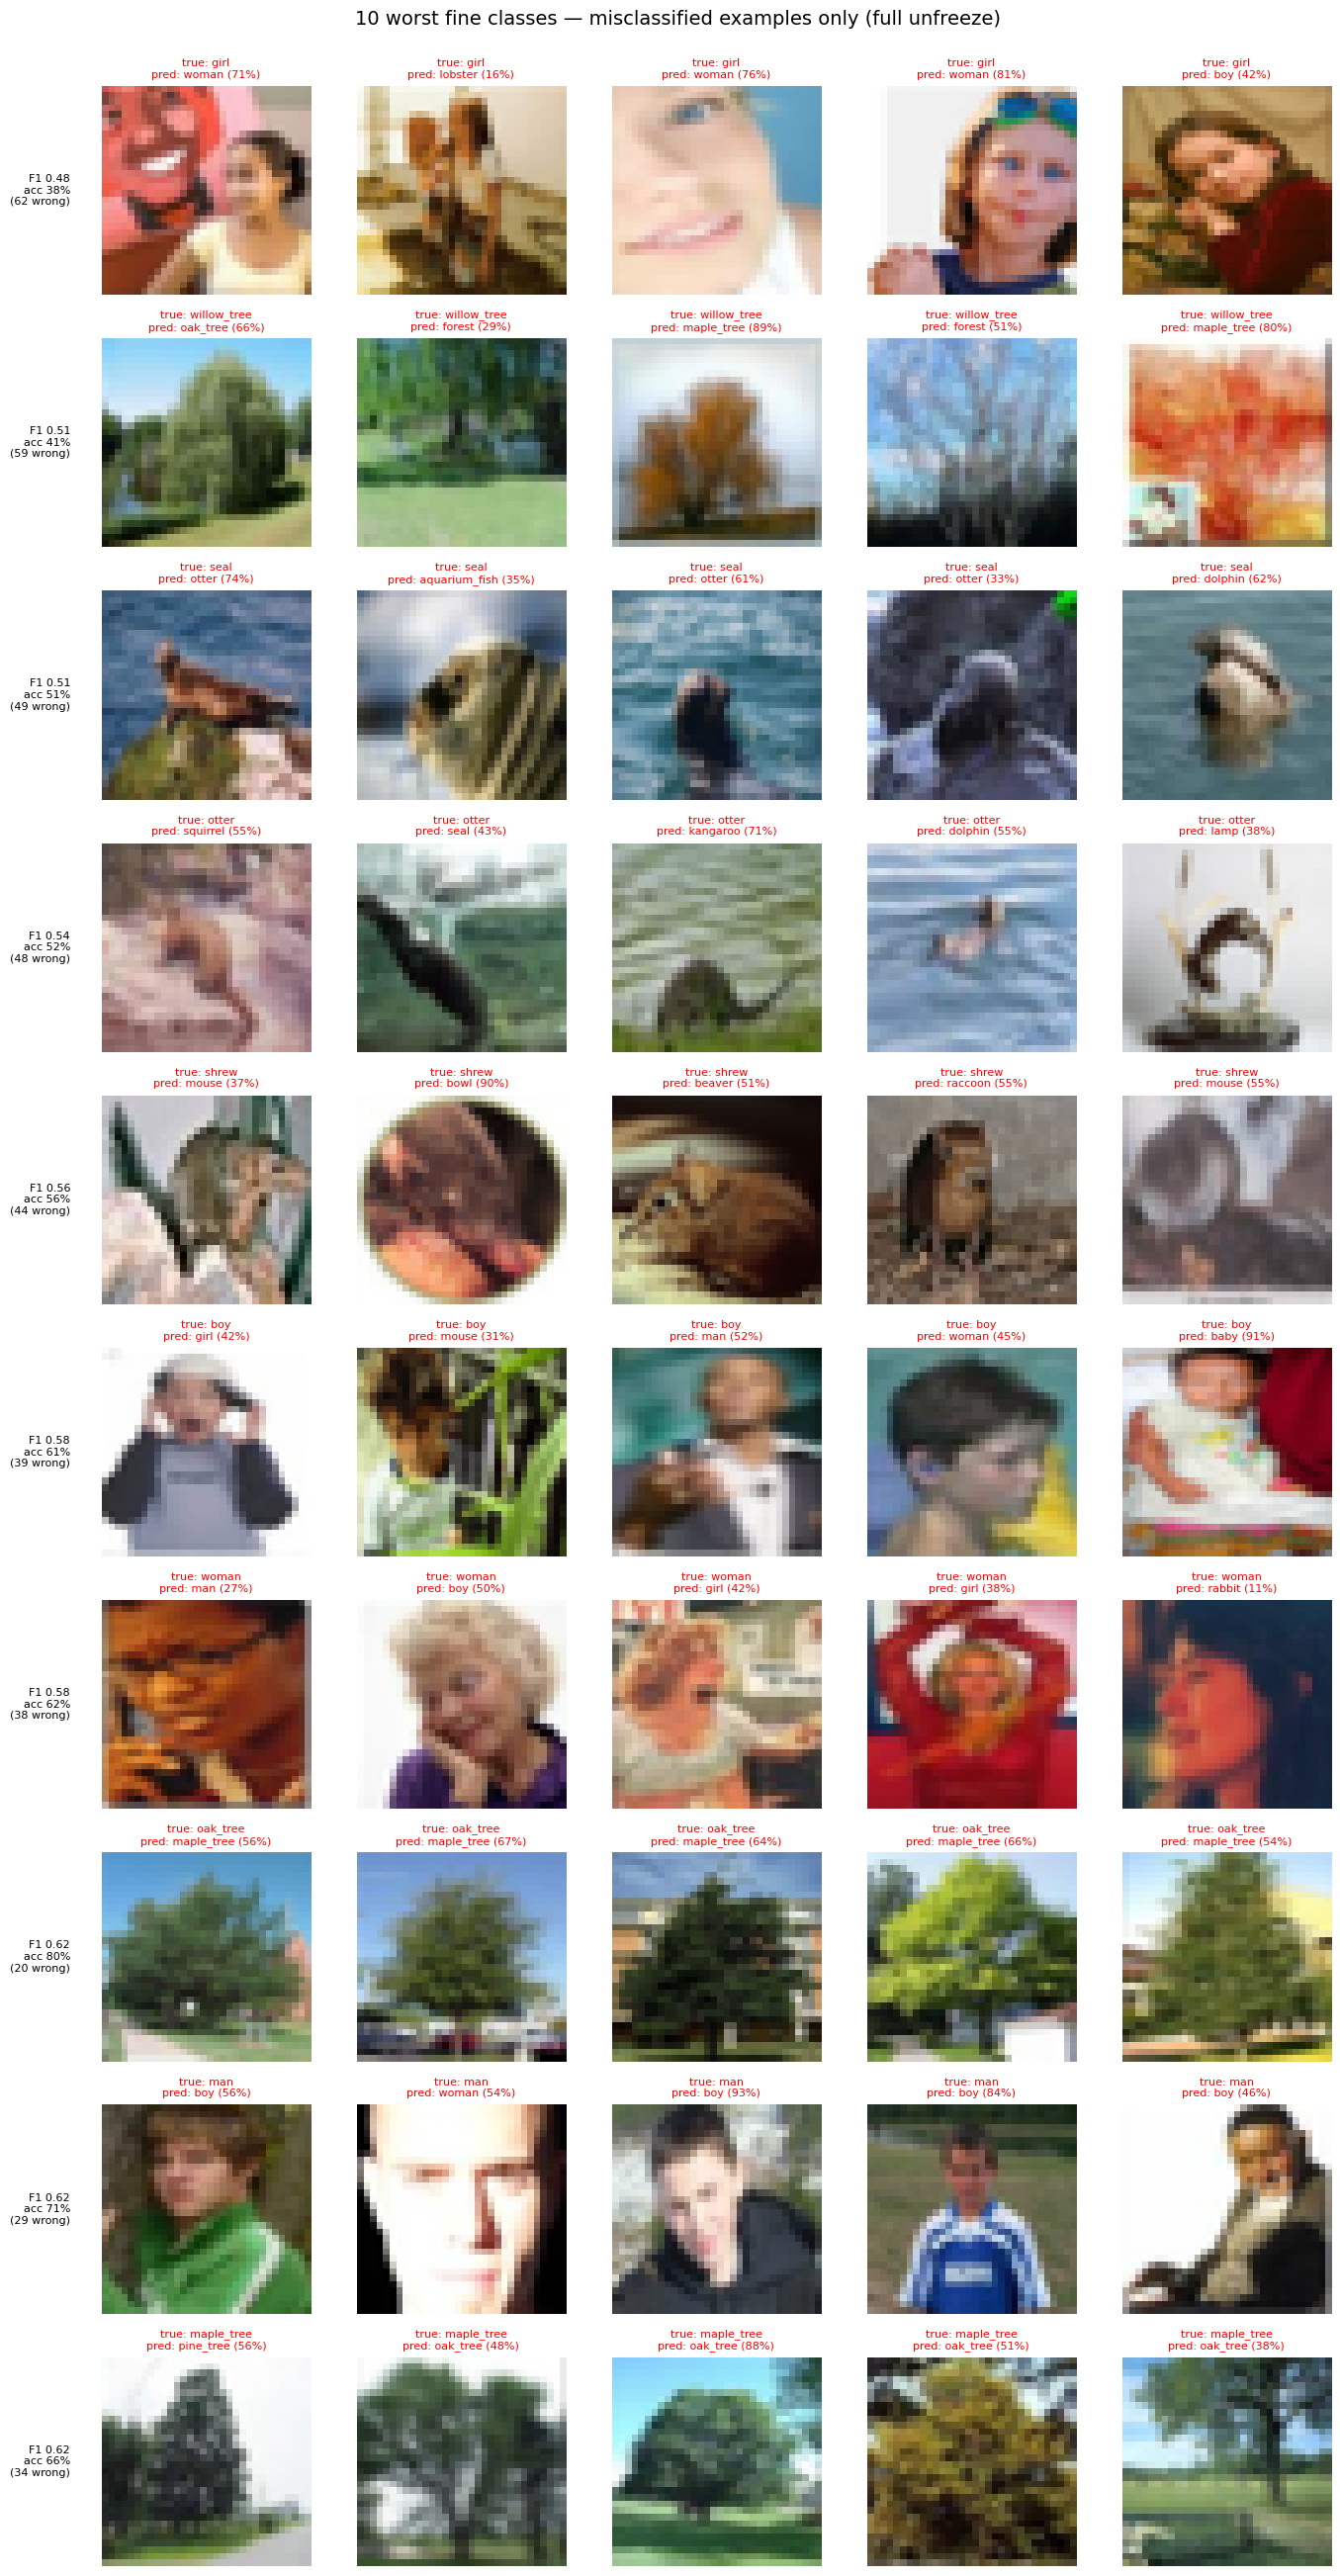

In [50]:
# %% ===== Worst-10 misclassified examples grid — FULL UNFREEZE =====
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

run_dir_ft = Path("results/efficientnet_b0_fine_ft/efficientnet_b0_fine_ft_in128_ep40")

with open(run_dir_ft / "metrics.json") as f:
    metrics_ft = json.load(f)

cm_ft = np.array(metrics_ft["confusion_matrix"])

diag = np.diag(cm_ft)
col_sums = cm_ft.sum(axis=0); row_sums = cm_ft.sum(axis=1)
precision_ft = np.divide(diag, col_sums, out=np.zeros_like(diag, float), where=col_sums != 0)
recall_ft    = np.divide(diag, row_sums, out=np.zeros_like(diag, float), where=row_sums != 0)
f1_ft = np.divide(2 * precision_ft * recall_ft, precision_ft + recall_ft,
                   out=np.zeros_like(diag, float), where=(precision_ft + recall_ft) != 0)

worst_ft = np.argsort(f1_ft)[:10]

# Rebuild the full-unfreeze model and predict on the test set
from data import load_cifar100
from data.tasks import make_cifar100_multiclass_task
from models.efficientnet_b0 import build_efficientnet_b0

test_split = load_cifar100("test")
test_task = make_cifar100_multiclass_task(test_split, label_level="fine", seed=42)
test_images = test_task.images
test_labels = test_task.labels

model_ft = build_efficientnet_b0(
    num_classes=100,
    freeze_backbone=False,
    unfreeze_from="all",
    freeze_bn=True,
    input_size=128,
)
model_ft.load_weights(run_dir_ft / "weights.h5")

test_images_normalized = test_images.astype(np.float32) / 255.0
probs_ft = model_ft.predict(test_images_normalized, batch_size=64, verbose=1)
preds_ft = probs_ft.argmax(axis=1)
confidences_ft = probs_ft.max(axis=1)

# Build the grid
fig, axes = plt.subplots(10, 5, figsize=(14, 26))

for row, cat_id in enumerate(worst_ft):
    category = FINE_LABELS[cat_id]
    is_this_class = test_labels == cat_id
    wrong_idx = np.flatnonzero(is_this_class & (preds_ft != cat_id))

    acc = (preds_ft[is_this_class] == cat_id).mean()
    n_wrong = len(wrong_idx)

    shown = wrong_idx[:5]
    for col in range(5):
        ax = axes[row, col]
        if col < len(shown):
            idx = shown[col]
            ax.imshow(test_images[idx])
            ax.set_title(
                f"true: {category}\npred: {FINE_LABELS[preds_ft[idx]]} ({confidences_ft[idx]:.0%})",
                fontsize=8, color="red"
            )
        ax.axis("off")
        if col == 0:
            ax.text(-0.15, 0.5, f"F1 {f1_ft[cat_id]:.2f}\nacc {acc:.0%}\n({n_wrong} wrong)",
                     transform=ax.transAxes, fontsize=8, va="center", ha="right")

fig.suptitle("10 worst fine classes — misclassified examples only (full unfreeze)", fontsize=14, y=1.0)
plt.tight_layout()
plt.savefig(run_dir_ft / "worst10_misclassified.png", dpi=150)
plt.show()

In [51]:
# %% Βεβαιώσου ότι είσαι στο σωστό branch
get_ipython().system('git branch')
get_ipython().system('git status')

* experiment/efficientnet-b0-fine
  main
On branch experiment/efficientnet-b0-fine
Your branch is up to date with 'origin/experiment/efficientnet-b0-fine'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   results/efficientnet_b0_fine_frozen/efficientnet_b0_fine_frozen_in128_ep30/history.csv
	modified:   results/efficientnet_b0_fine_frozen/efficientnet_b0_fine_frozen_in128_ep30/history.json
	modified:   results/efficientnet_b0_fine_frozen/efficientnet_b0_fine_frozen_in128_ep30/weights.h5
	modified:   results/efficientnet_b0_fine_ft/efficientnet_b0_fine_ft_in128_ep40/history.csv
	modified:   results/efficientnet_b0_fine_ft/efficientnet_b0_fine_ft_in128_ep40/history.json
	modified:   results/efficientnet_b0_fine_ft/efficientnet_b0_fine_ft_in128_ep40/per_class_f1_worst10.png
	modified:   results/efficientnet_b0_fine_ft/efficientnet_b0_fine_ft_in128_ep40/training_

In [55]:
get_ipython().system('pwd')
get_ipython().system('ls')

/content/deepl-cifar100-image-analysis
configs     experiments  pytest.ini		 requirements.txt  training
data	    models	 README.md		 results
evaluation  notebooks	 requirements-macos.txt  tests


In [56]:
# %% Clone the repo
get_ipython().system('git clone https://github.com/Fgram-devAI/deepl-cifar100-image-analysis.git')

Cloning into 'deepl-cifar100-image-analysis'...
remote: Enumerating objects: 710, done.
remote: Counting objects: 100% (125/125), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 710 (delta 63), reused 83 (delta 46), pack-reused 585 (from 2)
Receiving objects: 100% (710/710), 200.45 MiB | 26.31 MiB/s, done.
Resolving deltas: 100% (357/357), done.


In [57]:
# %% cd into it (no # in front of %cd!)
%cd /content/deepl-cifar100-image-analysis

/content/deepl-cifar100-image-analysis


In [58]:
# %% Checkout the existing branch (no -b, it already exists remotely)
get_ipython().system('git checkout experiment/efficientnet-b0-fine')
get_ipython().system('git status')

M	results/efficientnet_b0_fine_frozen/efficientnet_b0_fine_frozen_in128_ep30/history.csv
M	results/efficientnet_b0_fine_frozen/efficientnet_b0_fine_frozen_in128_ep30/history.json
M	results/efficientnet_b0_fine_frozen/efficientnet_b0_fine_frozen_in128_ep30/weights.h5
M	results/efficientnet_b0_fine_ft/efficientnet_b0_fine_ft_in128_ep40/history.csv
M	results/efficientnet_b0_fine_ft/efficientnet_b0_fine_ft_in128_ep40/history.json
M	results/efficientnet_b0_fine_ft/efficientnet_b0_fine_ft_in128_ep40/per_class_f1_worst10.png
M	results/efficientnet_b0_fine_ft/efficientnet_b0_fine_ft_in128_ep40/training_curves.png
M	results/efficientnet_b0_fine_ft/efficientnet_b0_fine_ft_in128_ep40/weights.h5
M	results/efficientnet_b0_fine_unfreeze_block6/efficientnet_b0_fine_unfreeze_block6_in128_ep30/history.csv
M	results/efficientnet_b0_fine_unfreeze_block6/efficientnet_b0_fine_unfreeze_block6_in128_ep30/history.json
M	results/efficientnet_b0_fine_unfreeze_block6/efficientnet_b0_fine_unfreeze_block6_in128_ep

In [63]:
from getpass import getpass
token = getpass("GitHub Personal Access Token: ")
get_ipython().system(f'git push https://{token}@github.com/Fgram-devAI/deepl-cifar100-image-analysis.git experiment/efficientnet-b0-fine')

GitHub Personal Access Token: ··········
Enumerating objects: 39, done.
Counting objects: 100% (39/39), done.
Delta compression using up to 2 threads
Compressing objects: 100% (23/23), done.
Writing objects: 100% (23/23), 30.60 MiB | 7.69 MiB/s, done.
Total 23 (delta 9), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (9/9), completed with 9 local objects.
To https://github.com/Fgram-devAI/deepl-cifar100-image-analysis.git
   36ca1eb..fff1c8f  experiment/efficientnet-b0-fine -> experiment/efficientnet-b0-fine


In [71]:
get_ipython().system('ls results/')


efficientnet_b0_fine_frozen  efficientnet_b0_fine_unfreeze_block6
efficientnet_b0_fine_ft      summary.csv


In [72]:
get_ipython().system('git ls-files results/')

results/.gitkeep
results/efficientnet_b0_fine_frozen/efficientnet_b0_fine_frozen_in128_ep30/class_balance.json
results/efficientnet_b0_fine_frozen/efficientnet_b0_fine_frozen_in128_ep30/config.yaml
results/efficientnet_b0_fine_frozen/efficientnet_b0_fine_frozen_in128_ep30/history.csv
results/efficientnet_b0_fine_frozen/efficientnet_b0_fine_frozen_in128_ep30/history.json
results/efficientnet_b0_fine_frozen/efficientnet_b0_fine_frozen_in128_ep30/metrics.json
results/efficientnet_b0_fine_frozen/efficientnet_b0_fine_frozen_in128_ep30/weights.h5
results/efficientnet_b0_fine_ft/efficientnet_b0_fine_ft_in128_ep40/class_balance.json
results/efficientnet_b0_fine_ft/efficientnet_b0_fine_ft_in128_ep40/config.yaml
results/efficientnet_b0_fine_ft/efficientnet_b0_fine_ft_in128_ep40/confusion_matrix.png
results/efficientnet_b0_fine_ft/efficientnet_b0_fine_ft_in128_ep40/history.csv
results/efficientnet_b0_fine_ft/efficientnet_b0_fine_ft_in128_ep40/history.json
results/efficientnet_b0_fine_ft/efficient

In [73]:
from getpass import getpass
token = getpass("GitHub Personal Access Token: ")
get_ipython().system(f'git push https://{token}@github.com/Fgram-devAI/deepl-cifar100-image-analysis.git experiment/efficientnet-b0-fine')

GitHub Personal Access Token: ··········
Everything up-to-date


In [ ]:
import json
from google.colab import _message
notebook_json = _message.blocking_request('get_ipynb', timeout_sec=30)
nb = notebook_json['ipynb']

with open('notebooks/b0_fine_100classes.ipynb', 'w') as f:
    json.dump(nb, f, indent=1)

get_ipython().system('git add -f notebooks/b0_fine_100classes.ipynb')
get_ipython().system('git commit -m "Add notebook with outputs and plots"')

from getpass import getpass
token = getpass("GitHub Personal Access Token: ")
get_ipython().system(f'git push https://{token}@github.com/Fgram-devAI/deepl-cifar100-image-analysis.git experiment/efficientnet-b0-fine')